 EXPERIMENT 6: CALCULATIONS & METRICS SUMMARY

[Mandatory Validation] Input 8-bit word: [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]
------------------------------------------------------------
Unipolar NRZ    | Avg Level:  0.500 | Max |RDS|:  400.0
Polar NRZ       | Avg Level:  0.000 | Max |RDS|:  200.0
Polar RZ        | Avg Level:  0.000 | Max |RDS|:  100.0
Manchester      | Avg Level:  0.000 | Max |RDS|:   50.0
Diff Manchester | Avg Level:  0.000 | Max |RDS|:   50.0
AMI             | Avg Level:  0.000 | Max |RDS|:  100.0
------------------------------------------------------------


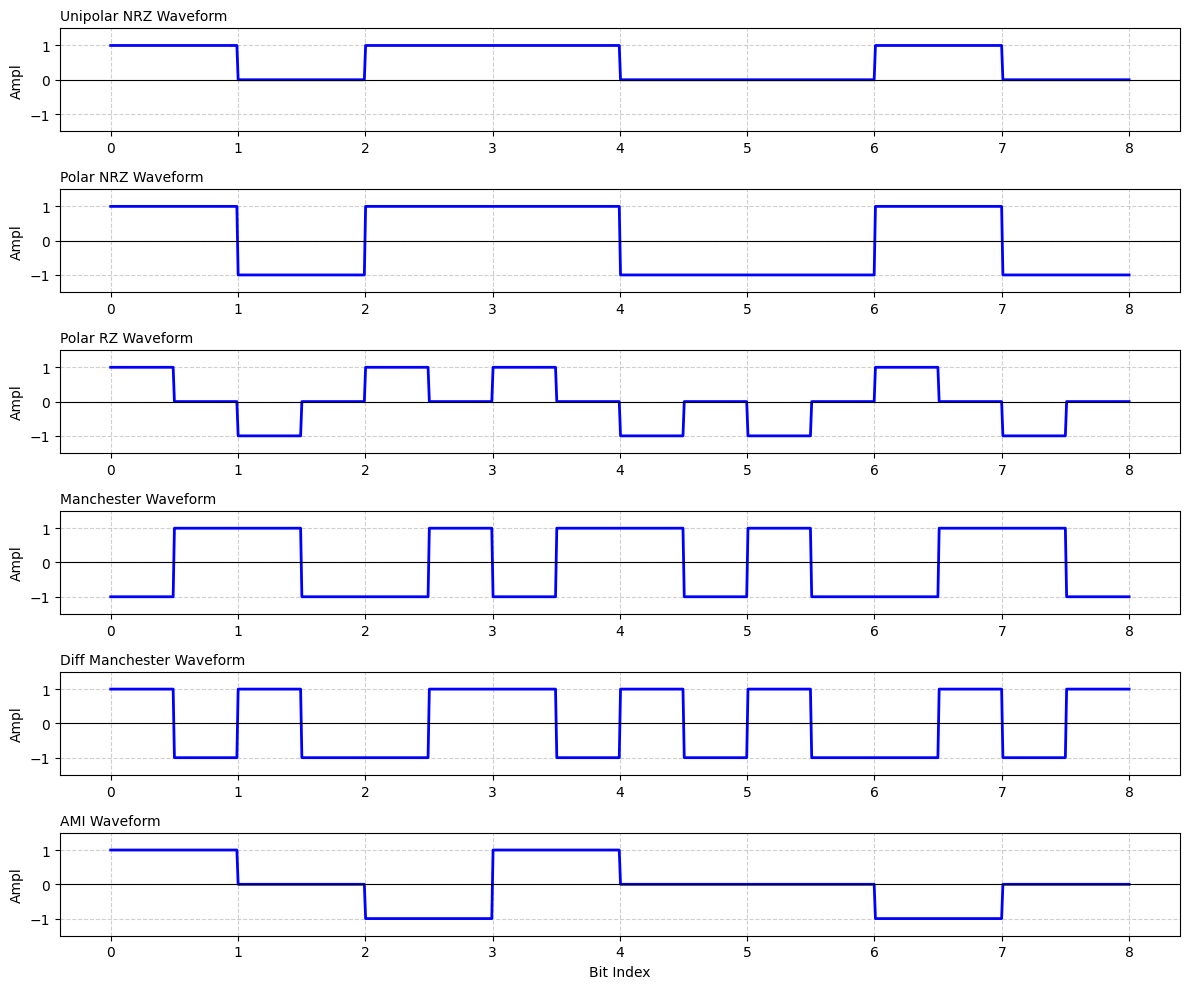

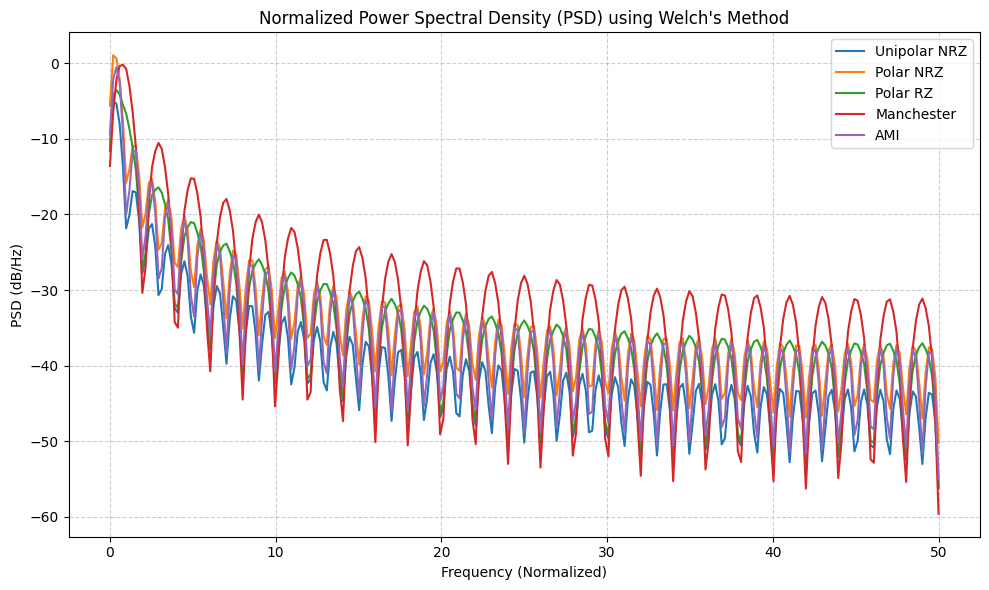

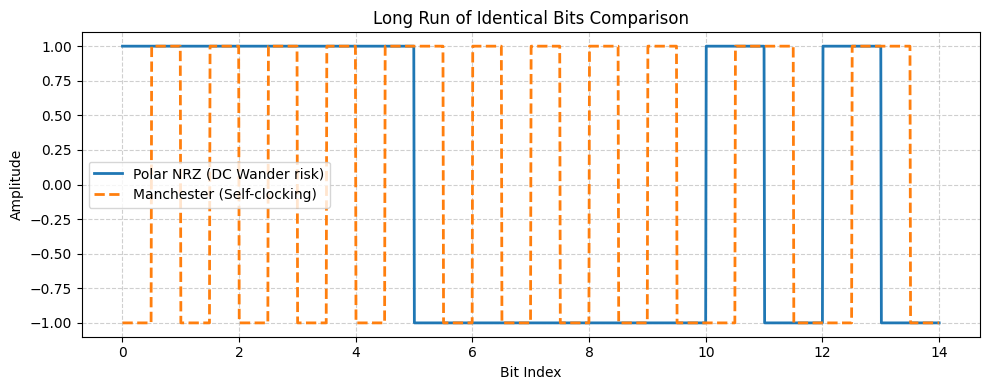

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# --- 1. SETUP PARAMETERS ---
bits_short = np.array([1, 0, 1, 1, 0, 0, 1, 0]) # For visualization & manual validation
np.random.seed(42)
bits_long = np.random.choice([0, 1], size=1000)   # For accurate PSD estimation
samples_per_bit = 100

def get_time_axis(num_bits):
    return np.linspace(0, num_bits, num_bits * samples_per_bit)

# --- 2. ENCODING FUNCTIONS (Manual Implementation) ---
def encode_unipolar_nrz(bits, spb):
    signal = np.repeat(bits, spb)
    return signal

def encode_polar_nrz(bits, spb):
    signal = np.where(bits == 1, 1.0, -1.0)
    return np.repeat(signal, spb)

def encode_polar_rz(bits, spb):
    signal = np.zeros(len(bits) * spb)
    half_spb = spb // 2
    for i, b in enumerate(bits):
        if b == 1:
            signal[i*spb : i*spb + half_spb] = 1.0
        else:
            signal[i*spb : i*spb + half_spb] = -1.0
    return signal

def encode_manchester(bits, spb):
    signal = np.zeros(len(bits) * spb)
    half_spb = spb // 2
    for i, b in enumerate(bits):
        if b == 1:
            signal[i*spb : i*spb + half_spb] = -1.0
            signal[i*spb + half_spb : (i+1)*spb] = 1.0
        else:
            signal[i*spb : i*spb + half_spb] = 1.0
            signal[i*spb + half_spb : (i+1)*spb] = -1.0
    return signal

def encode_diff_manchester(bits, spb):
    signal = np.zeros(len(bits) * spb)
    half_spb = spb // 2
    last_level = 1.0  # Initial transition state
    for i, b in enumerate(bits):
        if b == 0:  # Transition at the start of the bit interval
            last_level = -last_level
        # First half
        signal[i*spb : i*spb + half_spb] = last_level
        # Mid-bit transition
        last_level = -last_level
        signal[i*spb + half_spb : (i+1)*spb] = last_level
    return signal

def encode_ami(bits, spb):
    signal = np.zeros(len(bits) * spb)
    last_polarity = -1
    for i, b in enumerate(bits):
        if b == 1:
            last_polarity = -last_polarity
            signal[i*spb : (i+1)*spb] = last_polarity
        else:
            signal[i*spb : (i+1)*spb] = 0.0
    return signal

# --- 3. RUN CALCULATIONS & METRICS ---
print("="*60)
print(" EXPERIMENT 6: CALCULATIONS & METRICS SUMMARY")
print("="*60)

codes_dict = {
    "Unipolar NRZ": encode_unipolar_nrz(bits_short, samples_per_bit),
    "Polar NRZ": encode_polar_nrz(bits_short, samples_per_bit),
    "Polar RZ": encode_polar_rz(bits_short, samples_per_bit),
    "Manchester": encode_manchester(bits_short, samples_per_bit),
    "Diff Manchester": encode_diff_manchester(bits_short, samples_per_bit),
    "AMI": encode_ami(bits_short, samples_per_bit)
}

# Mandatory Validation: Print 8-bit word transition summary
print(f"\n[Mandatory Validation] Input 8-bit word: {list(bits_short)}")
print("-" * 60)
for name, sig in codes_dict.items():
    # Sample at bit centers or check transitions
    sampled_levels = [sig[i*samples_per_bit + samples_per_bit//2] for i in range(len(bits_short))]
    avg_level = np.mean(sig)

    # Running Digital Sum (RDS) calculation on short sequence
    rds = np.cumsum(sig)
    max_rds = np.max(np.abs(rds))

    print(f"{name:15s} | Avg Level: {avg_level:6.3f} | Max |RDS|: {max_rds:6.1f}")

print("-" * 60)

# --- 4. VISUALIZATIONS ---

# Figure 1: Aligned Waveforms
plt.figure(figsize=(12, 10))
t_short = get_time_axis(len(bits_short))
for idx, (name, sig) in enumerate(codes_dict.items(), 1):
    plt.subplot(6, 1, idx)
    plt.plot(t_short, sig, lw=2, color='b')
    plt.title(f"{name} Waveform", fontsize=10, loc='left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='black', lw=0.8)
    plt.ylim(-1.5, 1.5)
    plt.ylabel("Ampl")
plt.xlabel("Bit Index")
plt.tight_layout()
plt.show()

# Figure 2: Power Spectral Density (PSD) using Welch's Method
plt.figure(figsize=(10, 6))
fs = samples_per_bit # Sampling frequency
for name, enc_func in [
    ("Unipolar NRZ", encode_unipolar_nrz),
    ("Polar NRZ", encode_polar_nrz),
    ("Polar RZ", encode_polar_rz),
    ("Manchester", encode_manchester),
    ("AMI", encode_ami)
]:
    sig_long = enc_func(bits_long, samples_per_bit)
    frequencies, psd = welch(sig_long, fs=fs, nperseg=512)
    psd_db = 10 * np.log10(psd + 1e-10) # Convert to dB, avoid log(0)
    plt.plot(frequencies, psd_db, label=name, lw=1.5)

plt.title("Normalized Power Spectral Density (PSD) using Welch's Method")
plt.xlabel("Frequency (Normalized)")
plt.ylabel("PSD (dB/Hz)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Figure 3: Running Digital Sum (RDS) & Long Run Behavior
plt.figure(figsize=(10, 4))
long_run_bits = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0])
t_long_run = get_time_axis(len(long_run_bits))
sig_nrz_longrun = encode_polar_nrz(long_run_bits, samples_per_bit)
sig_manc_longrun = encode_manchester(long_run_bits, samples_per_bit)

plt.plot(t_long_run, sig_nrz_longrun, label="Polar NRZ (DC Wander risk)", lw=2)
plt.plot(t_long_run, sig_manc_longrun, label="Manchester (Self-clocking)", lw=2, linestyle='--')
plt.title("Long Run of Identical Bits Comparison")
plt.xlabel("Bit Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()